In [40]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from shapely.ops import unary_union
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Geometry is in a geographic CRS.*")
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

In [3]:
# Load in the 1966 boundaries with names matched to ICRISAT data
icri_path = "../shapefiles/icrisat_apportioned/icrisat_boundary_match.shp"
icri = gpd.read_file(icri_path)

In [9]:
#Create national boundaries
india_unary = unary_union(icri.geometry)
india_boundary = gpd.GeoDataFrame(geometry=[india_unary], crs=icri.crs)

In [4]:
colname1 = "Dist_Name"
icri['name'] = icri[colname1]

In [37]:
#Load in the ICRISAT apportioned data
icri_apportioned_path = '../shapefiles/icrisat_apportioned/ICRISAT-District Level Data_Apportioned.csv'
df = pd.read_csv(icri_apportioned_path)
icri = icri.rename(columns={'Name_12': 'Dist Name', 'NAME_1' : 'State Name'})
icri.loc[icri['State Name']== "Uttaranchal", "State Name"] = "Uttar Pradesh"
merged_icri = gpd.GeoDataFrame(icri.merge(df, how="left", on=['Dist Name', 'State Name']))

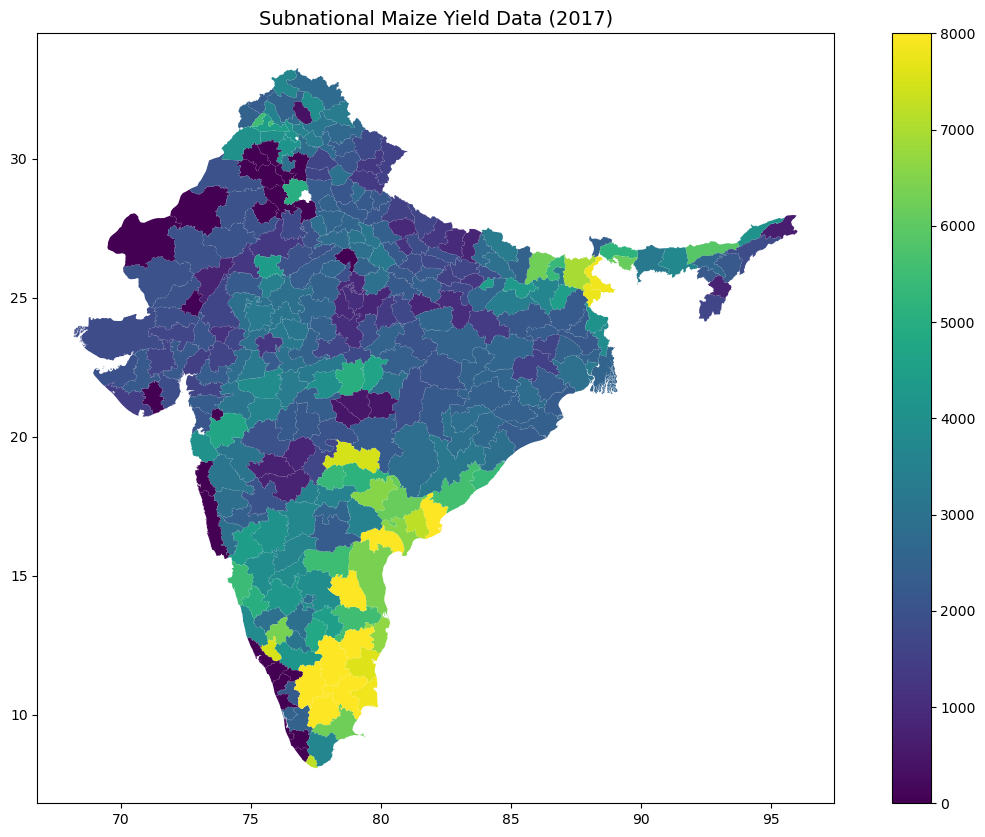

In [50]:
# Define common colorbar parameters
vmin = 0
vmax = 8000
cmap = 'viridis'

# Plot 1: Subnational data (multiple values)
fig, ax = plt.subplots(figsize=(15, 10))
merged_icri[merged_icri['Year'] == 2017].plot(
    ax=ax, 
    column="MAIZE YIELD (Kg per ha)", 
    cmap=cmap,
    vmin=vmin, 
    vmax=vmax, 
    legend=True
)
ax.set_title('Subnational Maize Yield Data (2017)', fontsize=14)
plt.show()

In [51]:
# Load in the 1966 boundaries with names matched to ICRISAT data
fao_path = "../../data/Pivoted_FAOSTAT_data_IN_09032025.csv"
fao = gpd.read_file(fao_path)
fao['geometry'] = india_boundary.geometry.iloc[0]
fao = gpd.GeoDataFrame(fao, geometry='geometry', crs=india_boundary.crs)

In [52]:
fao_crop.columns

Index(['Domain Code', 'Area Code (M49)', 'Area', 'Item Code (CPC)', 'Item',
       'Year', 'Area harvested [ha]', 'Yield [kg/ha]', 'Production [t]',
       'geometry'],
      dtype='object')

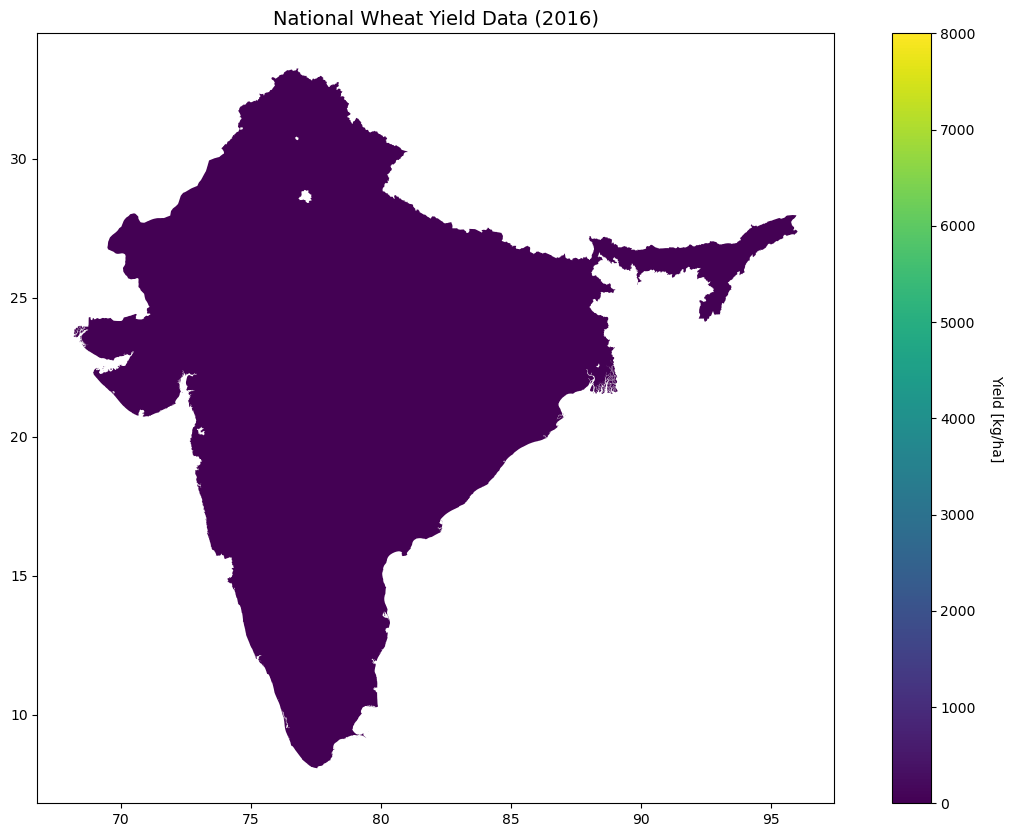

In [53]:
# Plot 2: National data (single value)
crop = 'Wheat'
year = '2016'
fao_crop = fao[(fao['Item'] == crop) & (fao['Year'] == year)]

fig, ax = plt.subplots(figsize=(15, 10))

# Create a norm object for consistent color mapping
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Plot the data with the normalized colormap
fao_crop.plot(
    ax=ax, 
    column='Yield [kg/ha]', 
    cmap=cmap, 
    norm=norm,
    legend=False  # We'll create a custom colorbar
)

# Create a custom colorbar with the fixed range
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # This is required for matplotlib
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Yield [kg/ha]', rotation=270, labelpad=20)

ax.set_title(f'National {crop} Yield Data ({year})', fontsize=14)
plt.show()

In [54]:
fao_crop

,Domain Code,Area Code (M49),Area,Item Code (CPC),Item,Year,Area harvested [ha],Yield [kg/ha],Production [t],geometry
55,QCL,356,India,111.0,Wheat,2016,30420000.0,3033.9,92290000.0,"MULTIPOLYGON (((68.61042 23.22958, 68.61069 23..."


/var/folders/16/y9h7_0ld1418y9zts1sf_3xh0000gn/T/ipykernel_7383/2799503403.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)
/var/folders/16/y9h7_0ld1418y9zts1sf_3xh0000gn/T/ipykernel_7383/2799503403.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


National yield value: 3033.9 kg/ha
Data type: <class 'numpy.float64'>


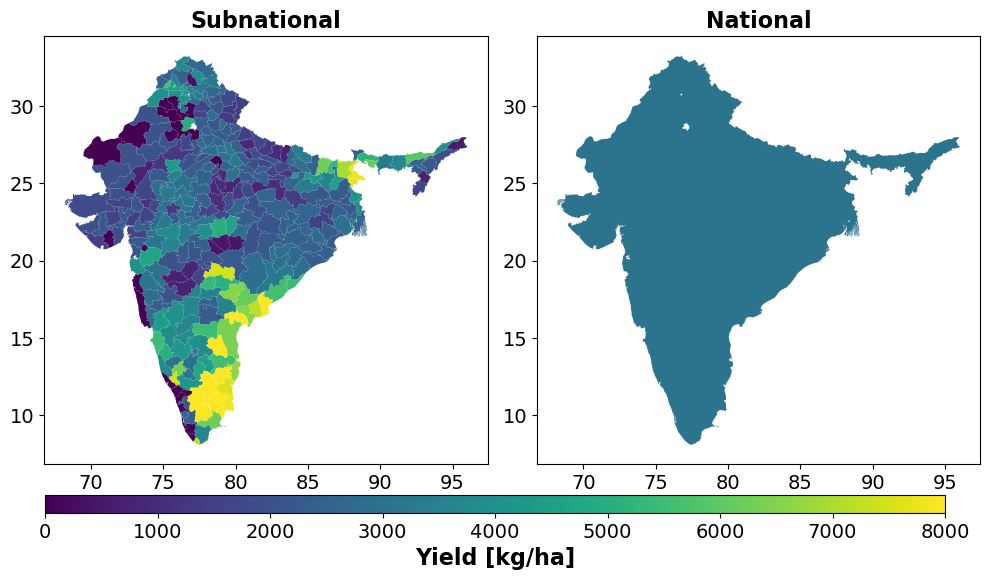

In [112]:
#Alternative: Create both plots side by side with the same colorbar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Create a consistent norm for both plots
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap_obj = plt.cm.get_cmap(cmap)

# Plot subnational data with the norm
merged_icri[merged_icri['Year'] == 2017].plot(
    ax=ax1, 
    column="MAIZE YIELD (Kg per ha)", 
    cmap=cmap,
    norm=norm,  # Use norm instead of vmin/vmax
    legend=False
)
ax1.set_title('Subnational', fontsize=16, fontweight='bold')
ax1.tick_params(axis='both', labelsize=14)

# For national data with single value, manually set the color
# Get the actual yield value and ensure it's numeric
yield_col = 'Yield [kg/ha]'
# Convert to numeric, handling any string values
fao_crop[yield_col] = pd.to_numeric(fao_crop[yield_col], errors='coerce')
yield_value = fao_crop[yield_col].iloc[0]
print(f"National yield value: {yield_value} kg/ha")  # Debug print
print(f"Data type: {type(yield_value)}")  # Check the data type

# Check if the value is valid
if pd.isna(yield_value):
    print("Warning: Yield value is NaN. Using default color.")
    color = 'gray'
    yield_display = 'N/A'
else:
    # Calculate the color based on the normalized value
    normalized_value = norm(float(yield_value))
    color = cmap_obj(normalized_value)
    yield_display = f'{yield_value:.0f}'

# Plot with the manually calculated color
fao_crop.plot(
    ax=ax2, 
    color=color,  # Use the manually calculated color
    legend=False
)
ax2.set_title(f'National',
              fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)

# Create a single colorbar at the bottom of both plots
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# Use fig.add_axes to precisely position the colorbar
cbar_ax = fig.add_axes([0.05, 0.1, 0.9, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Yield [kg/ha]', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Make room for colorbar
plt.savefig('../plots/subnational_vs_national_yield.png')
plt.show()

# Maize timeseries

In [85]:
merged_icri.columns

Index(['NAME_0', 'ID_0', 'ISO', 'ID_1', 'State Name', 'ID_2', 'NAME_2',
       'TYPE_2', 'ENGTYPE_2', 'NL_NAME_2',
       ...
       'SUGARCANE YIELD (Kg per ha)', 'COTTON AREA (1000 ha)',
       'COTTON PRODUCTION (1000 tons)', 'COTTON YIELD (Kg per ha)',
       'FRUITS AREA (1000 ha)', 'VEGETABLES AREA (1000 ha)',
       'FRUITS AND VEGETABLES AREA (1000 ha)', 'POTATOES AREA (1000 ha)',
       'ONION AREA (1000 ha)', 'FODDER AREA (1000 ha)'],
      dtype='object', length=107)

In [91]:
fao_wheat = fao[(fao['Item'] == crop)]

icri_yearly_area = merged_icri.groupby('Year')[crop.upper() + ' AREA (1000 ha)'].sum()*1000
icri_yearly_production = merged_icri.groupby('Year')[crop.upper() + ' PRODUCTION (1000 tons)'].sum()*1000
icri_years = merged_icri[merged_icri[crop.upper() + ' AREA (1000 ha)'].notna()]['Year'].unique()

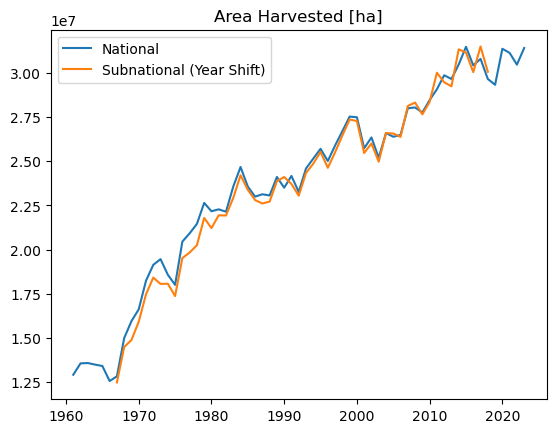

In [98]:
plt.plot(fao_wheat['Year'].astype(int), fao_wheat['Area harvested [ha]'].astype(float), label='National')
plt.plot(icri_years+1, icri_yearly_area, label='Subnational (Year Shift)')
plt.title('Area Harvested [ha]')
plt.legend()

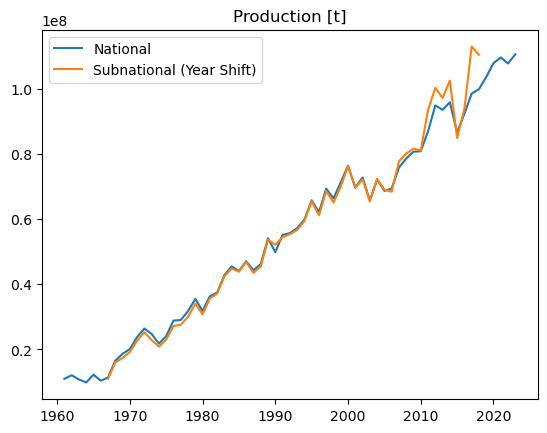

In [97]:
plt.plot(fao_wheat['Year'].astype(int), fao_wheat['Production [t]'].astype(float), label='National')
plt.plot(icri_years+1, icri_yearly_production, label='Subnational (Year Shift)')
plt.title('Production [t]')
plt.legend()